## HateXplain - 7 OBJECTIVES

### Multi Task Learning

* **Dataset:** HateXplain
* **Task :** Classification

* **Target 1:** Hate speech against Women
* **Target 2:** Hate speech against Homosexual
* **Target 3:** Hate speech against African
* **Target 4:** Hate speech against Asian
* **Target 5:** Hate speech against Jewish
* **Target 6:** Hate speech against Islam

In [8]:
%load_ext autoreload
%autoreload 2

In [ ]:
import dill
import pickle
import torch
from datasets import load_dataset

/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
from machinemoo import moo
from machinemoo import get_objectives, get_models
from machinemoo.analysis.visualization import plot_pareto, plot_multiple_hypervolumes
from machinemoo.analysis.metrics import compute_hypervolume_progress

import preprocessing as pp
from scalarization import NLPScalarization

In [11]:
# Setting a seed for reproducibility
from machinemoo.utils.seed_config import set_np_torch_seed
set_np_torch_seed(42)

In [13]:
PREFIX_SAVE_IMAGE = 'images/10_objs'

In [24]:
PREFIX_SAVE_RESULT = '10_objs'

## Dataset and Model

In [15]:
# Get HateXplain Dataset
dataset = load_dataset("Hate-speech-CNERG/hatexplain", trust_remote_code=True)

# Choose BERT model
model_name="bert-base-uncased"

In [16]:
# Use GPU if its available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda:0


In [ ]:
task_config = {
    "Women": {"type": "group_hate", "group": "Women"},
    "Homosexual": {"type": "group_hate", "group": "Homosexual"},
    "African": {"type": "group_hate", "group": "African"},
    "Asian": {"type": "group_hate", "group": "Asian"},
    "Jewish": {"type": "group_hate", "group": "Jewish"},
    "Islam": {"type": "group_hate", "group": "Islam"},    
}

train_dataloader = pp.get_dataloader(dataset['train'], task_config)

## MOO Modeling and Training

* MOO methods:
    * MOLA
    * Random Weights

In [34]:
# Setting optimization parameter to use in all methods in this experiment
opt_params = {
    'node_time_limit': 2,
    'target_size': 500,
    'target_gap': 0,
    'node_gap': 0.05,
    'norm': False
}
results = {}
objectives_names = list(task_config.keys())

# Control optimization output (Default is False):
#   verbose=True -> show optimization progress
#   debug=True   -> show detailed debug information
verbose = False
debug = False

def machine_optimize(method, lb_estimate=0.01):
    w_scalar = NLPScalarization(
        train_dataloader = train_dataloader, 
        device = device, 
        task_names = objectives_names, 
        lower_bound_estimate=0.01
    )
    moopt = moo(w_scalar, verbose=verbose, debug=debug).mo_optimization(method, **opt_params)
    objs = get_objectives(moopt)
    if method == 'mola':
        hypervolume_values = moopt.get_hypervolumes()
    else:
        hypervolume_values = compute_hypervolume_progress(objs)
    if lb_estimate == 'lipschitz':
        method = f'{method}_grad'
    results[method] = {
                    "moopt": moopt,
                    "objectives": objs,
                    "models": get_models(moopt),
                    "hypervolume": hypervolume_values
                }
    
def plot_frontier(method, color="#d73027"):
    title="Loss Trade-offs in Multi-Group Hate Speech Detection"
    plot_pareto(methods={method: results[method]['objectives']},
                labels=objectives_names, 
                #title=title,
                color=color,
                fontsize=25,
                figsize=(10,7),
                save_path=f'{PREFIX_SAVE_IMAGE}_{method}.pdf'
                )

### MOLA

In [12]:
method = 'mola'
machine_optimize(method=method)

load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


...

load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/pandas/plotting/_matplotlib/misc.py:422: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper right")
/home/lineccsa/mestrado/machinemoo/machinemoo/analysis/visualization.py:287: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  leg = ax.legend(fontsize=fontsize - 13, loc="upper right")


<Figure size 1000x700 with 0 Axes>

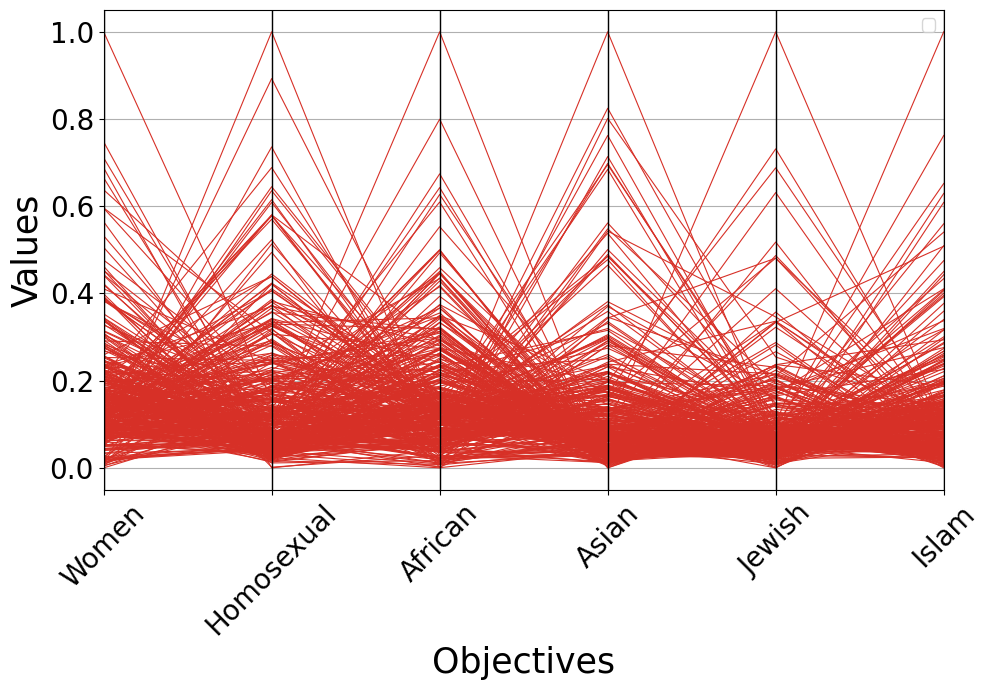

In [39]:
plot_frontier('mola', color='#d73027')

In [14]:
# save results
import dill
with open(f"results_{PREFIX_SAVE_RESULT}.pkl", "wb") as f:
    dill.dump(results, f)

### MOLA with gradient

In [15]:
method = 'mola'
machine_optimize(method=method, lb_estimate='lipschitz')

load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


...

load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/pandas/plotting/_matplotlib/misc.py:422: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper right")
/home/lineccsa/mestrado/machinemoo/machinemoo/analysis/visualization.py:287: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  leg = ax.legend(fontsize=fontsize - 13, loc="upper right")


<Figure size 1000x700 with 0 Axes>

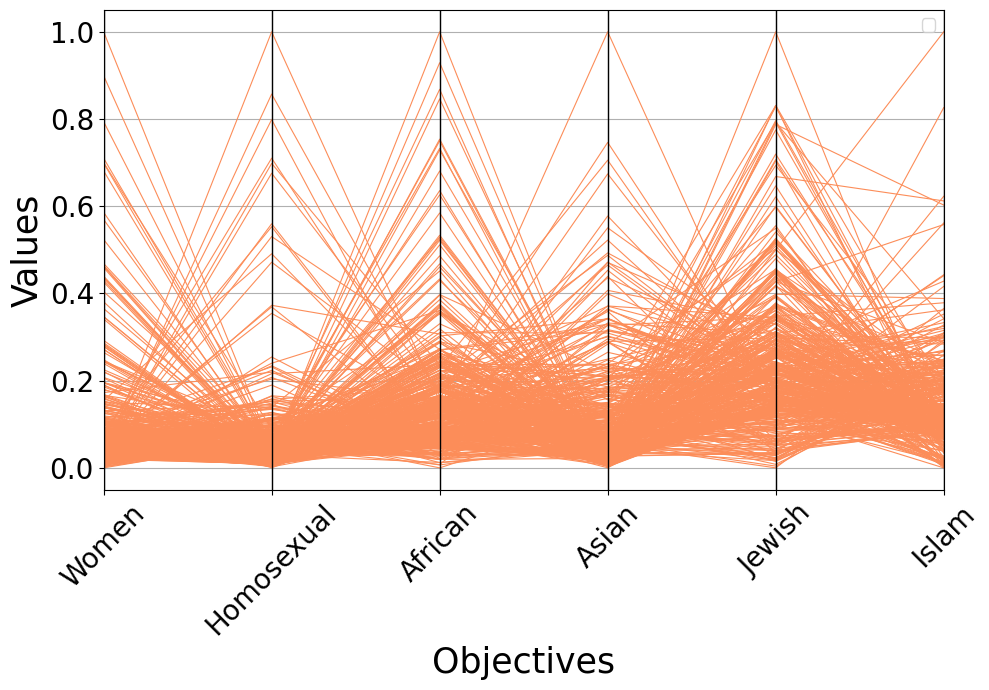

In [43]:
plot_frontier(f'mola_grad', color='#fc8d59')

In [17]:
# save results
with open(f"results_{PREFIX_SAVE_RESULT}.pkl", "wb") as f:
    dill.dump(results, f)

### Random Weight

In [18]:
method = 'random_weights'
machine_optimize(method=method)

### Non-dominated Solutions Analysis

In [26]:
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting
rw_solutions = results['random_weights']['objectives']
nd_indices = NonDominatedSorting().do(rw_solutions, only_non_dominated_front=True)
rw_non_dominated_solutions = rw_solutions[nd_indices]

print(f'Number of non-dominated solutions with MOLA          : {len(results['mola']['objectives'])}')
print(f'Number of non-dominated solutions with MOLA GRAD     : {len(results['mola_grad']['objectives'])}')
print(f'Number of non-dominated solutions with RANDOM WEIGHT : {len(rw_non_dominated_solutions)}')

Number of non-dominated solutions with MOLA          : 372
Number of non-dominated solutions with MOLA GRAD     : 416
Number of non-dominated solutions with RANDOM WEIGHT : 396


/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/pandas/plotting/_matplotlib/misc.py:422: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper right")
/home/lineccsa/mestrado/machinemoo/machinemoo/analysis/visualization.py:287: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  leg = ax.legend(fontsize=fontsize - 13, loc="upper right")


<Figure size 1000x700 with 0 Axes>

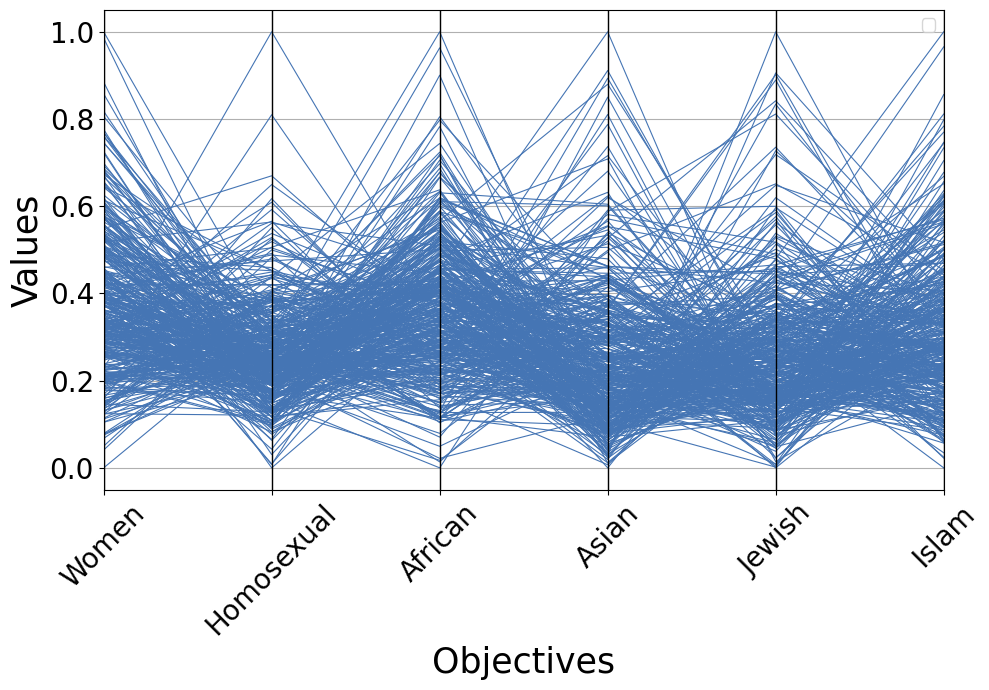

In [30]:
plot_pareto(methods={'random_weights': rw_non_dominated_solutions},
                labels=objectives_names, 
                #title=title,
                color="#4575b4",
                fontsize=25,
                figsize=(10,7),
                save_path=f'{PREFIX_SAVE_IMAGE}_random_weights.pdf'
                )

## A posteriori Decision Making

* Comparison between MOO methods
* Ensemble and Evaluation

/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/pandas/plotting/_matplotlib/misc.py:422: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper right")
/home/lineccsa/mestrado/machinemoo/machinemoo/analysis/visualization.py:287: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  leg = ax.legend(fontsize=fontsize - 13, loc="upper right")
/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/pandas/plotting/_matplotlib/misc.py:422: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper right")
/home/lineccsa/mestrado/machinemoo/machinemoo/analysis/visuali

<Figure size 3000x700 with 0 Axes>

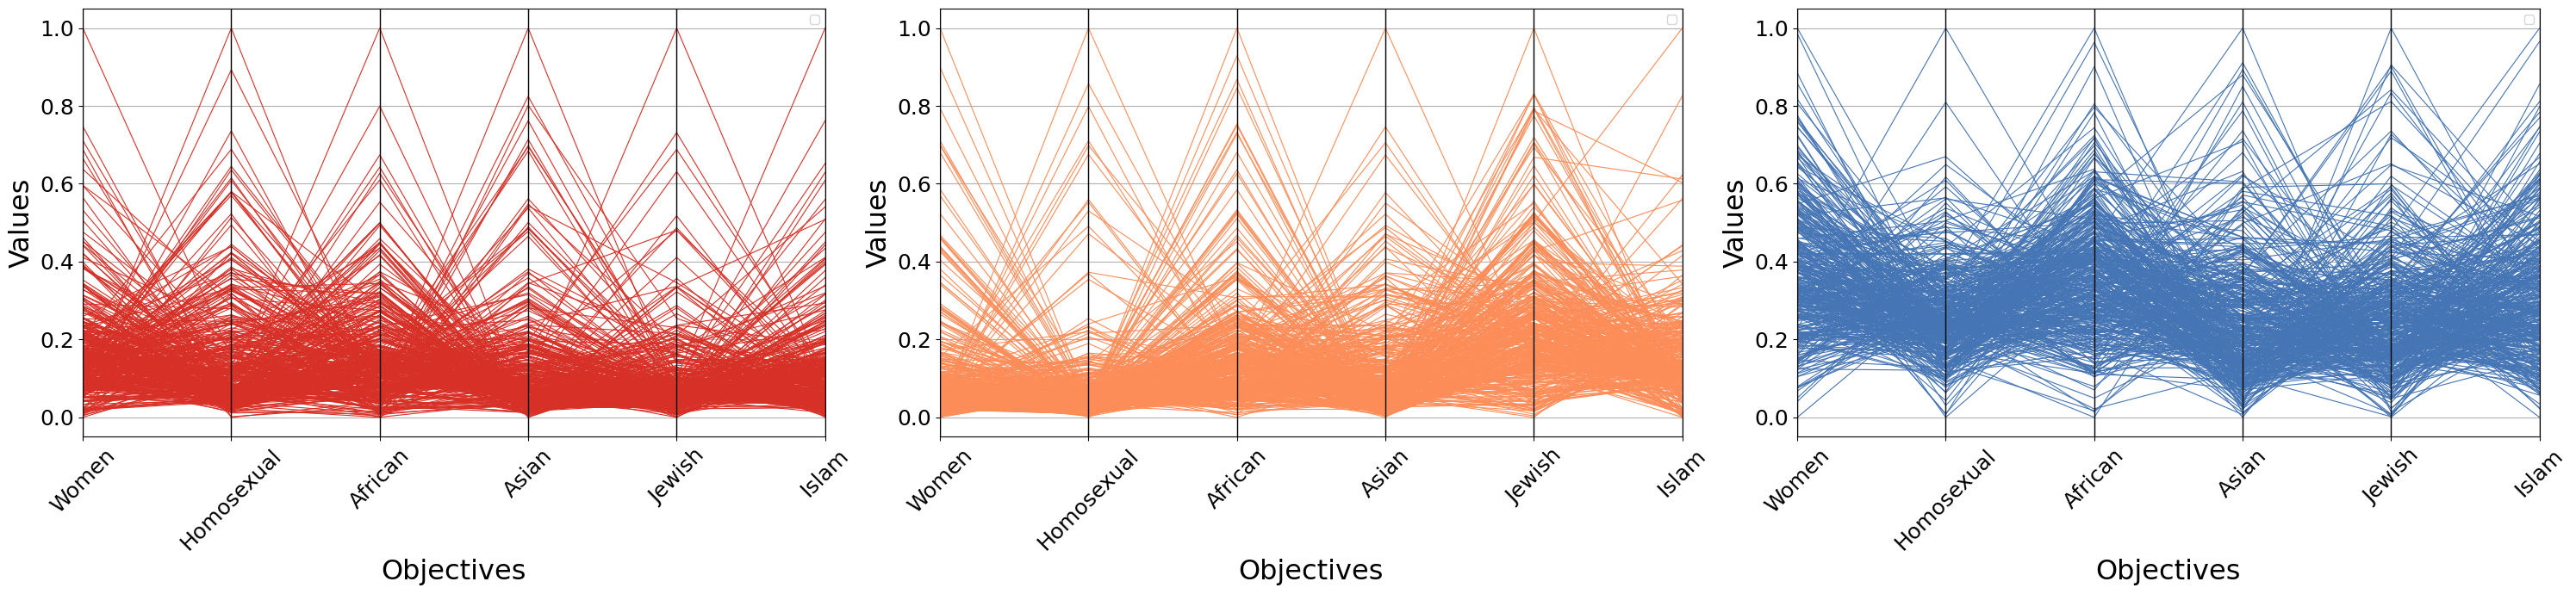

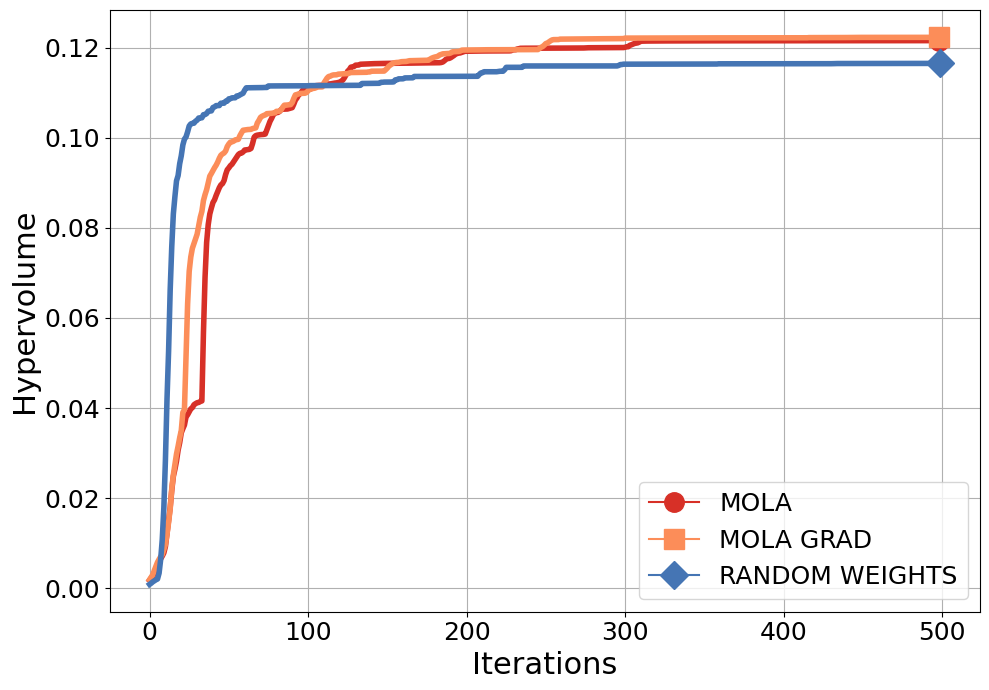

In [27]:
pareto_dict = {
        method: res['objectives']
        for method, res in results.items()
        if 'objectives' in res
    }

pareto_dict['random_weights'] = rw_non_dominated_solutions

hypervolumes_dict = {
        method: res['hypervolume']
        for method, res in results.items()
        if 'hypervolume' in res
    }

plot_pareto(methods=pareto_dict,
            labels=objectives_names, 
            #title='Comparative Pareto Frontiers Across MOO Methods',
            #subset=equal.objs,
            fontsize=23,
            figsize=(10,7),
            save_path=f'{PREFIX_SAVE_IMAGE}_methods.pdf'
            )

plot_multiple_hypervolumes(methods_hv=hypervolumes_dict, save_path=f'{PREFIX_SAVE_IMAGE}_hypervolume.pdf')

In [ ]:
# save results
with open(f"results_{PREFIX_SAVE_RESULT}.pkl", "wb") as f:
    dill.dump(results, f)

# get saved results
# with open(f"results_{PREFIX_SAVE_RESULT}.pkl", "rb") as f:
#     results = pickle.load(f)

In [60]:
from machinemoo.analysis.decision import topsis_model_selection

import torch
import torch.nn as nn
import numpy as np

def compute_val_losses(
    models,
    val_loader,
    task_names,
    device
):
    """
    Computes the validation loss matrix.
    
    Args:
        models: list of trained models
        val_loader: DataLoader for the validation set
        objectives: list of loss functions (one per objective)

    Returns:
        losses: tensor with shape (n_models, n_objectives)
    """
    n_obj = len(task_names)
    #objs = torch.zeros((n_models, n_obj), dtype=torch.float32)

    val_losses = []
    for model in models:
        total_batches = 0
        eval_losses = np.zeros(n_obj)
        model.eval()
        criterion = nn.CrossEntropyLoss()
        with torch.no_grad():
            for batch in val_loader:
                embeddings = batch["embedding"].to(device)
                logits_dict = model(embeddings)
                for i, task in enumerate(task_names):
                    labels = batch[task].to(device)
                    loss = criterion(logits_dict[task], labels)
                    eval_losses[i] += loss.item()
                total_batches += 1
        # eval_losses /= len(self.train_dataloader)
        eval_losses /= total_batches
        val_losses.append(eval_losses)

    return np.array(val_losses)


In [61]:
val_dataloader = pp.get_dataloader(dataset['validation'], task_config)

In [62]:
val_losses = compute_val_losses(
    models=results['mola']['models'],
    val_loader=val_dataloader,
    task_names=task_config,
    device=device
)

In [63]:
topsis_res = topsis_model_selection(val_losses)


/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/pandas/plotting/_matplotlib/misc.py:422: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper right")


<Figure size 1000x700 with 0 Axes>

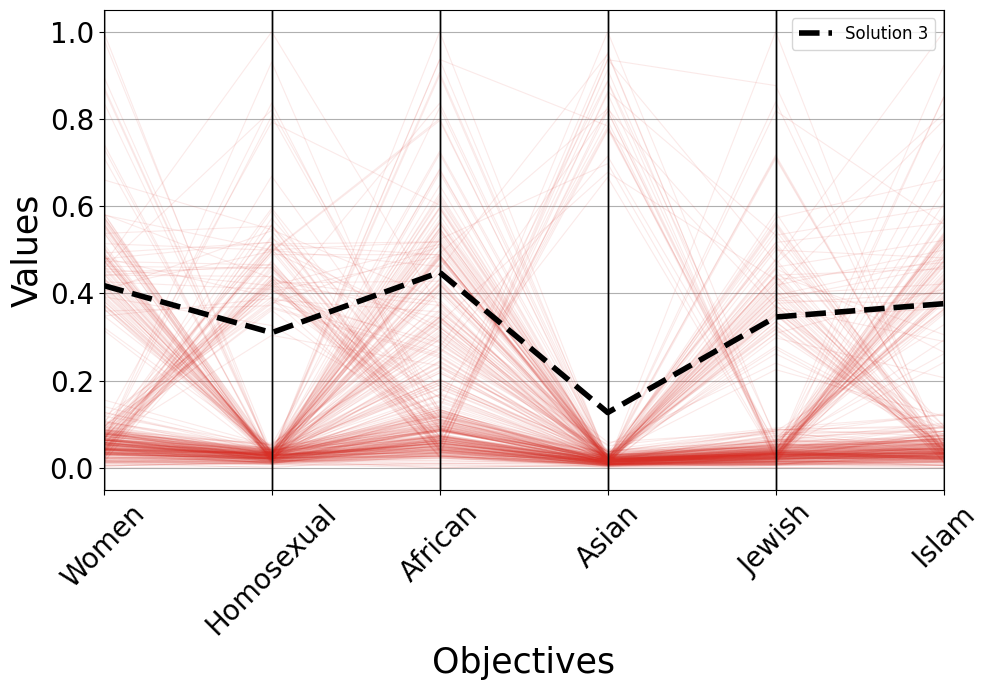

In [64]:
plot_pareto(methods={'mola': val_losses},
            labels=objectives_names, 
            #title=title,
            fontsize=25,
            figsize=(10,7),
            subset=topsis_res[3],
            subset_label=f'Solution {topsis_res[1]}',
            save_path=f'{PREFIX_SAVE_IMAGE}_mola_topsis.pdf',
            alpha=0.1,
            s_factor=5,
            )

In [65]:
topsis_res = topsis_model_selection(val_losses, weights=[0.4, 0.1, 0.1, 0.1, 0.1, 0.1])


/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/pymcdm/validators.py:578: UserWarning: Weights should be positive and its sum should be equal one. Now, sum of the weights is 0.8999999999999999.
  warn('Weights should be positive and its sum should be equal one. Now, sum of the weights is '


/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/pandas/plotting/_matplotlib/misc.py:422: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper right")


<Figure size 1000x700 with 0 Axes>

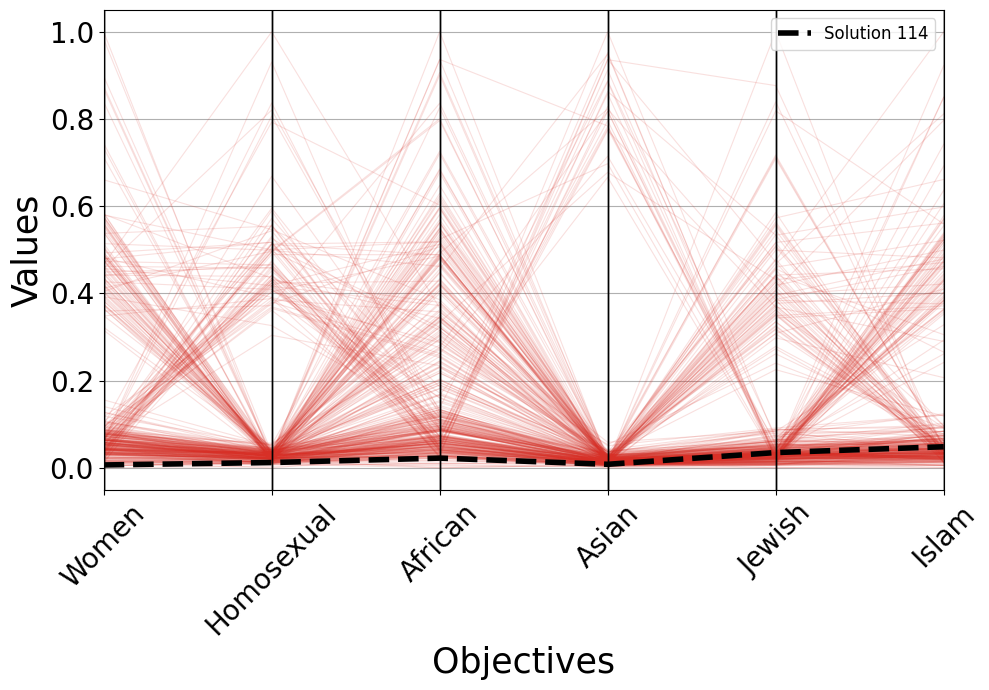

In [66]:
plot_pareto(methods={'mola': val_losses},
            labels=objectives_names, 
            #title=title,
            fontsize=25,
            figsize=(10,7),
            subset=topsis_res[3],
            subset_label=f'Solution {topsis_res[1]}',
            save_path=f'{PREFIX_SAVE_IMAGE}_mola_topsis_weighted.pdf',
            alpha=0.15,
            s_factor=5,
            #color='grey',
            #subset_color="#a50026"
            )